# Spatial2D Inference Debug Notebook

This notebook keeps the wrapper logic minimal and calls the real source interfaces directly so you can debug the full system rather than a notebook-specific reimplementation.

Main call chain:

1. `src.inference.load_model_and_transform`
2. `src.viaABC.systems.Spatial2D`
3. `Spatial2D.sample_priors`
4. `Spatial2D.simulate`
5. `viaABC.run`

Because the current viaABC implementation computes particle variances and covariances, using `num_particles = 1` is not recommended. Start from `2` for debugging.


In [1]:
import re
from pathlib import Path

import rootutils

rootutils.setup_root(Path.cwd(), indicator=".project-root", pythonpath=True)

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.colors import ListedColormap
from omegaconf import OmegaConf
from PIL import Image

from src.inference import load_model_and_transform
from src.viaABC.systems import Spatial2D

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [2]:
# -----------------------------
# 1. Configuration
# -----------------------------
PROJECT_ROOT = Path(rootutils.find_root(Path.cwd(), indicator=".project-root"))
SAMPLE_ID = "sample_1"

# Update this to a training run directory that exists on your local machine.
RUN_FOLDER_PATH = PROJECT_ROOT / "run" / "train" / "spatial2D" / "2026-04-06_14-24-25_job8472267"
CHECKPOINT_SUBSTR = "last"

# Keep the inference tiny but still numerically valid for debugging.
ABC_DEBUG_CFG = {
    "num_particles": 2,
    "k": 1,
    "q_threshold": 0.90,
    "max_generations": 1,
    "num_workers": 10,
    "simulation_batch_size": 1,
    "max_pending_simulations": 1,
}

if ABC_DEBUG_CFG["num_particles"] < 2:
    raise ValueError("Please keep num_particles >= 2 for debugging.")

BASE_INFERENCE_CFG = OmegaConf.load(PROJECT_ROOT / "configs" / "inference.yaml")
SPATIAL2D_INFERENCE_CFG = OmegaConf.load(PROJECT_ROOT / "configs" / "inference" / "spatial2D.yaml")
DATA_CFG = OmegaConf.load(PROJECT_ROOT / "configs" / "data" / "spatial2D.yaml")
INFERENCE_CFG = OmegaConf.merge(BASE_INFERENCE_CFG, SPATIAL2D_INFERENCE_CFG)
INFERENCE_CFG.data = DATA_CFG

PARAM_NAMES = ["alpha", "beta", "gamma"]
STATE_CMAP = ListedColormap([
    "#d73027",
    "#fee08b",
    "#4575b4",
    "#2b1744",
    "#1a9850",
    "#d9d9d9",
])

print("RUN_FOLDER_PATH:", RUN_FOLDER_PATH)
print("SAMPLE_ID:", SAMPLE_ID)
print("ABC_DEBUG_CFG:", ABC_DEBUG_CFG)


RUN_FOLDER_PATH: /home/kangyu/project/viaABC/run/train/spatial2D/2026-04-06_14-24-25_job8472267
SAMPLE_ID: sample_1
ABC_DEBUG_CFG: {'num_particles': 2, 'k': 1, 'q_threshold': 0.9, 'max_generations': 1, 'num_workers': 10, 'simulation_batch_size': 1, 'max_pending_simulations': 1}


In [3]:
# -----------------------------
# 2. Minimal helper logic
# -----------------------------
sample_cfg = OmegaConf.to_container(INFERENCE_CFG.data.observation_samples[SAMPLE_ID], resolve=False)
txt_path = Path(str(sample_cfg["txt"]).replace("${paths.data_dir}", str(PROJECT_ROOT / "data")))

image_candidates = []
if sample_cfg.get("image") is not None:
    image_candidates.append(Path(str(sample_cfg["image"]).replace("${paths.data_dir}", str(PROJECT_ROOT / "data"))))

match = re.search(r"(\d+)$", SAMPLE_ID)
if match is not None:
    idx = match.group(1)
    image_candidates.extend([
        PROJECT_ROOT / "data" / "spatial2D" / f"img{idx}.jpg",
        PROJECT_ROOT / "data" / "spatial2D" / f"image{idx}_processed.jpg",
        PROJECT_ROOT / "data" / "spatial2D" / f"image{idx}.jpg",
    ])

raw_image_path = next((path for path in image_candidates if path.exists()), None)


def draw_grid(ax, grid, title):
    ax.imshow(grid, cmap=STATE_CMAP, vmin=0, vmax=5)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])


def weighted_quantile(values, quantile, weights):
    values = np.asarray(values)
    weights = np.asarray(weights)
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cumulative = np.cumsum(weights) - 0.5 * weights
    cumulative = cumulative / weights.sum()
    return np.interp(quantile, cumulative, values)


/home/kangyu/micromamba/envs/viaabc310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/kangyu/micromamba/envs/viaabc310/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.
INFO:src.viaABC.viaABC:Initializing viaABC class
INFO:src.viaABC.viaABC:Model updated
INFO:src.viaABC.viaABC:viaABC class initialized with the following parameters:
INFO:src.viaABC.viaABC:num_parameters: 3
INFO:src.viaABC.viaABC:Mu: [0. 0. 0.]
INFO:src.viaABC.viaABC:Sigma: [1. 1. 1.]
INFO:src.viaABC.viaABC:t0: 0
INFO:src.viaABC.viaABC:tmax: 24
INFO:src.viaABC.viaABC:time_space: None
INFO:src.viaABC.viaABC:pooling_method: no_cls
INFO:src.v

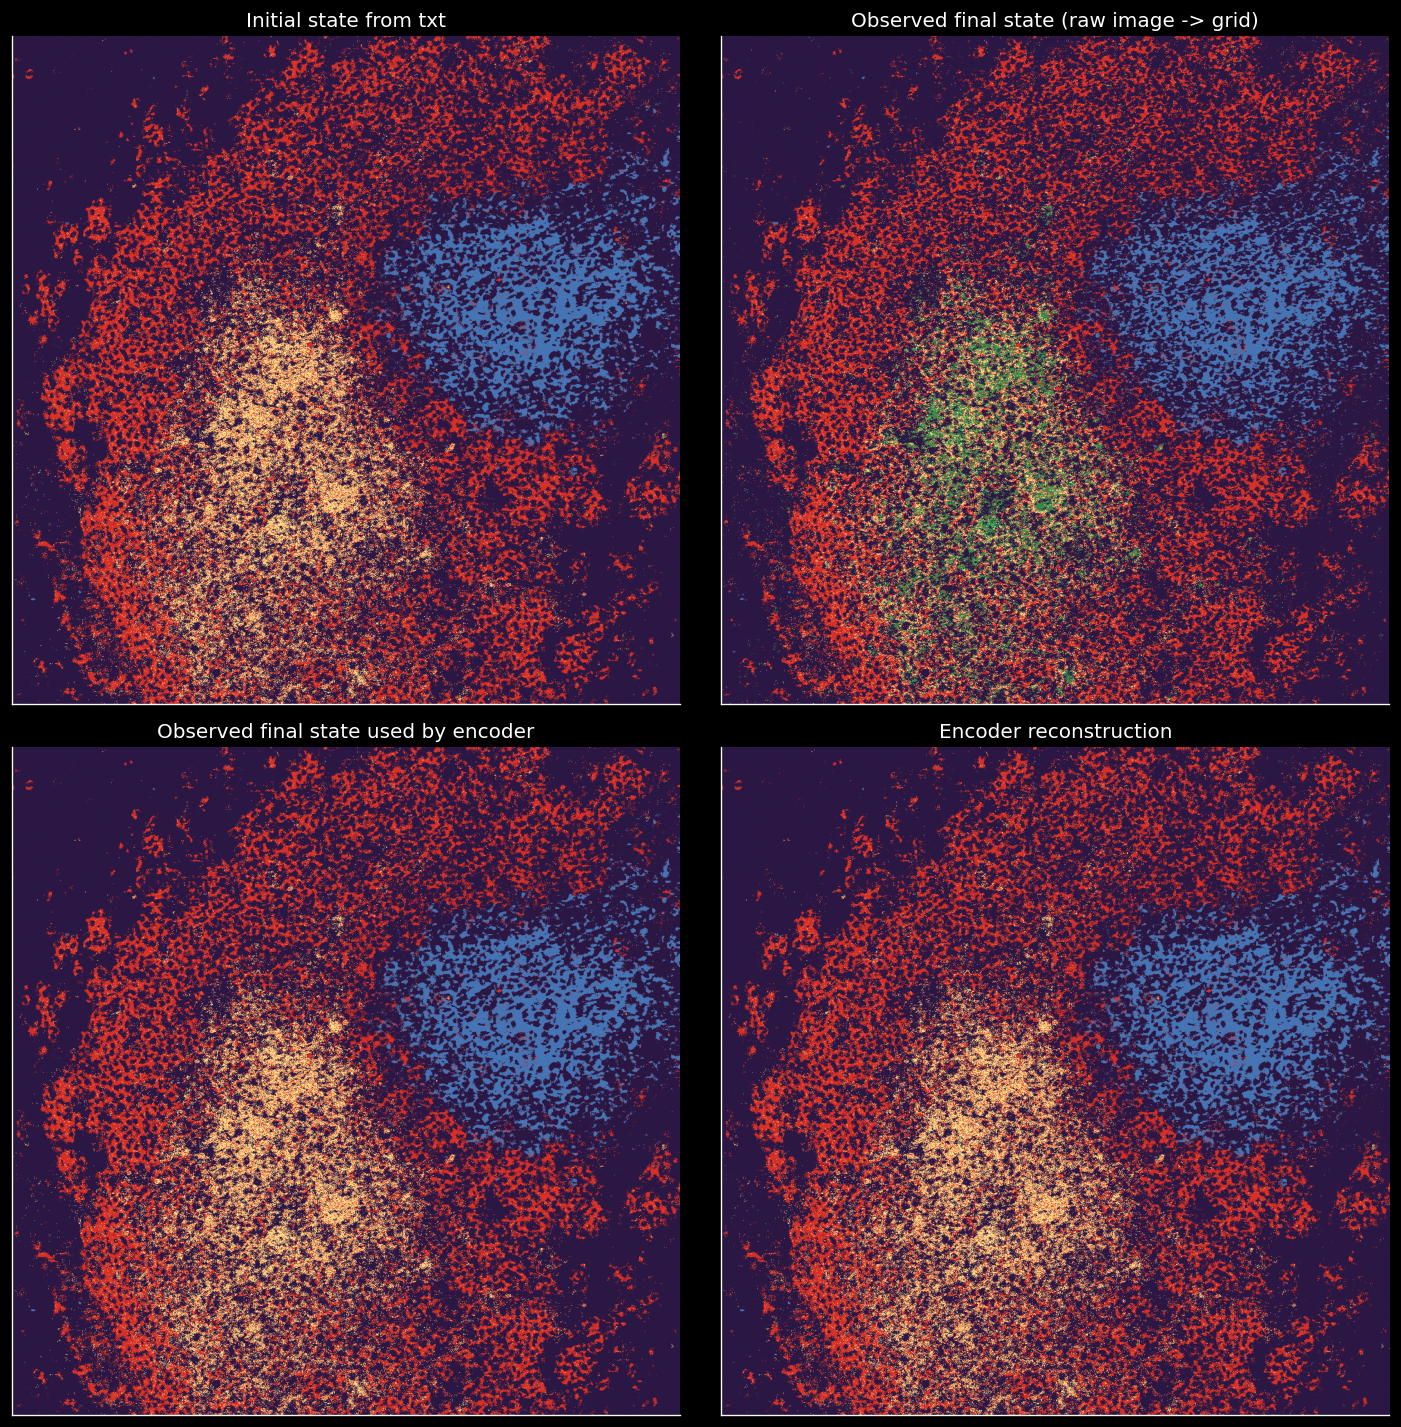

txt path: /home/kangyu/project/viaABC/data/spatial2D/initial_grid1_cpp.txt
raw image path: /home/kangyu/project/viaABC/data/spatial2D/img1.jpg
device: cuda:0
transform: None
encoded observation shape: (1, 5625, 256)


In [4]:
# -----------------------------
# 3. Load the real model and the real system interface
# -----------------------------
runtime_cfg = OmegaConf.create({
    "run_folder_path": str(RUN_FOLDER_PATH),
    "checkpoint_substr": CHECKPOINT_SUBSTR,
})

model, transform = load_model_and_transform(runtime_cfg)

system = Spatial2D(
    model=model,
    transform=transform,
    sample_id=SAMPLE_ID,
    pooling_method=INFERENCE_CFG.system.pooling_method,
    metric=INFERENCE_CFG.system.metric,
)

initial_grid = np.loadtxt(txt_path, dtype=np.uint8)
observed_grid = system._observation_grids[0]
raw_image = np.array(Image.open(raw_image_path)) if raw_image_path is not None else None
raw_image_grid = system.image_to_grid(raw_image) if raw_image is not None else None

obs_tensor = torch.from_numpy(system.observational_data).unsqueeze(0).float().to(model.device)
with torch.no_grad():
    recon_tokens = model.model.forward(obs_tensor)[-1]
    recon_grid = model.model.unpatchify(recon_tokens).detach().cpu().numpy()[0].argmax(axis=0)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
draw_grid(axes[0, 0], initial_grid, "Initial state from txt")
if raw_image is not None:
    draw_grid(axes[0, 1], raw_image_grid, "Observed final state (raw image -> grid)")
else:
    draw_grid(axes[0, 1], observed_grid, "Observed final state")
draw_grid(axes[1, 0], observed_grid, "Observed final state used by encoder")
draw_grid(axes[1, 1], recon_grid, "Encoder reconstruction")
fig.tight_layout()
plt.show()

print("txt path:", txt_path)
print("raw image path:", raw_image_path)
print("device:", model.device)
print("transform:", type(transform).__name__ if transform is not None else None)
print("encoded observation shape:", system.encoded_observational_data.shape)


smoke theta: [0.8692 0.225  0.3125]
smoke status: 0
smoke distance: 0.017395734786987305


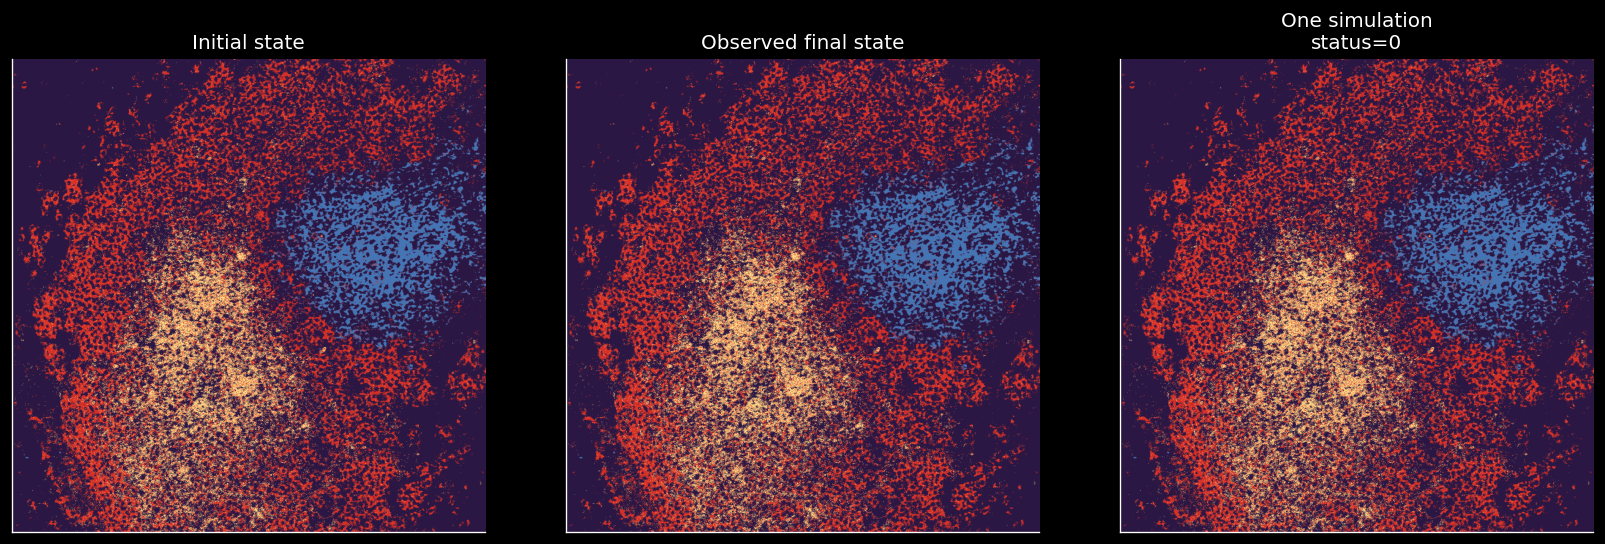

In [5]:
# -----------------------------
# 4. Single-step smoke test
# Set breakpoints here to inspect sample_priors, simulate, and distance.
# -----------------------------
smoke_theta = system.sample_priors()
smoke_sim, smoke_status = system.simulate(smoke_theta)
smoke_distance = np.nan if smoke_status != 0 else system._calculate_particle_distance(smoke_sim)

print("smoke theta:", np.round(smoke_theta, 4))
print("smoke status:", smoke_status)
print("smoke distance:", float(smoke_distance) if np.isfinite(smoke_distance) else smoke_distance)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
draw_grid(axes[0], initial_grid, "Initial state")
draw_grid(axes[1], observed_grid, "Observed final state")
draw_grid(axes[2], smoke_sim, f"One simulation\nstatus={smoke_status}")
fig.tight_layout()
plt.show()


In [6]:
# -----------------------------
# 5. Small-scale inference
# Set breakpoints here to inspect _run_init, _run_generation, and _calculate_particle_weight.
# -----------------------------
abc_system = Spatial2D(
    model=model,
    transform=transform,
    sample_id=SAMPLE_ID,
    pooling_method=INFERENCE_CFG.system.pooling_method,
    metric=INFERENCE_CFG.system.metric,
)

abc_system.run(
    num_particles=ABC_DEBUG_CFG["num_particles"],
    k=ABC_DEBUG_CFG["k"],
    q_threshold=ABC_DEBUG_CFG["q_threshold"],
    max_generations=ABC_DEBUG_CFG["max_generations"],
    num_workers=ABC_DEBUG_CFG["num_workers"],
    simulation_batch_size=ABC_DEBUG_CFG["simulation_batch_size"],
    max_pending_simulations=ABC_DEBUG_CFG["max_pending_simulations"],
)

last_generation = abc_system.generations[-1]
posterior_particles = last_generation["particles"]
posterior_weights = last_generation["weights"]

posterior_mean = np.average(posterior_particles, axis=0, weights=posterior_weights)
posterior_std = np.sqrt(np.average((posterior_particles - posterior_mean) ** 2, axis=0, weights=posterior_weights))
posterior_median = np.array([
    weighted_quantile(posterior_particles[:, i], 0.5, posterior_weights)
    for i in range(posterior_particles.shape[1])
])
map_params = posterior_particles[np.argmax(posterior_weights)]

print("Finished generations:", len(abc_system.generations))
print("Last epsilon:", float(last_generation["epsilon"]))
print("Posterior mean  :", np.round(posterior_mean, 4))
print("Posterior std   :", np.round(posterior_std, 4))
print("Posterior median:", np.round(posterior_median, 4))
print("MAP particle    :", np.round(map_params, 4))


INFO:src.viaABC.systems:Spatial2D sample sample_1: initial txt=/home/kangyu/project/viaABC/data/spatial2D/initial_grid1_cpp.txt, observed raw image=/home/kangyu/project/viaABC/data/spatial2D/image1_processed.jpg, observed final grid source=txt fallback, shape=(1200, 1200)
INFO:src.viaABC.viaABC:Initializing viaABC class
INFO:src.viaABC.viaABC:Model updated
INFO:src.viaABC.viaABC:viaABC class initialized with the following parameters:
INFO:src.viaABC.viaABC:num_parameters: 3
INFO:src.viaABC.viaABC:Mu: [0. 0. 0.]
INFO:src.viaABC.viaABC:Sigma: [1. 1. 1.]
INFO:src.viaABC.viaABC:t0: 0
INFO:src.viaABC.viaABC:tmax: 24
INFO:src.viaABC.viaABC:time_space: None
INFO:src.viaABC.viaABC:pooling_method: no_cls
INFO:src.viaABC.viaABC:metric: pairwise_cosine
INFO:src.viaABC.viaABC:Starting viaABC run with Q Threshold: 0.9
INFO:src.viaABC.viaABC:Using 2 worker threads for particle simulations
INFO:src.viaABC.viaABC:Initialization (generation 0) started
INFO:src.viaABC.viaABC:Initialization completed in 

Finished generations: 2
Last epsilon: 0.017395734786987305
Posterior mean  : [0.6378 0.6222 0.5418]
Posterior std   : [0.0188 0.0857 0.1368]
Posterior median: [0.6378 0.6222 0.5418]
MAP particle    : [0.6285 0.58   0.6093]


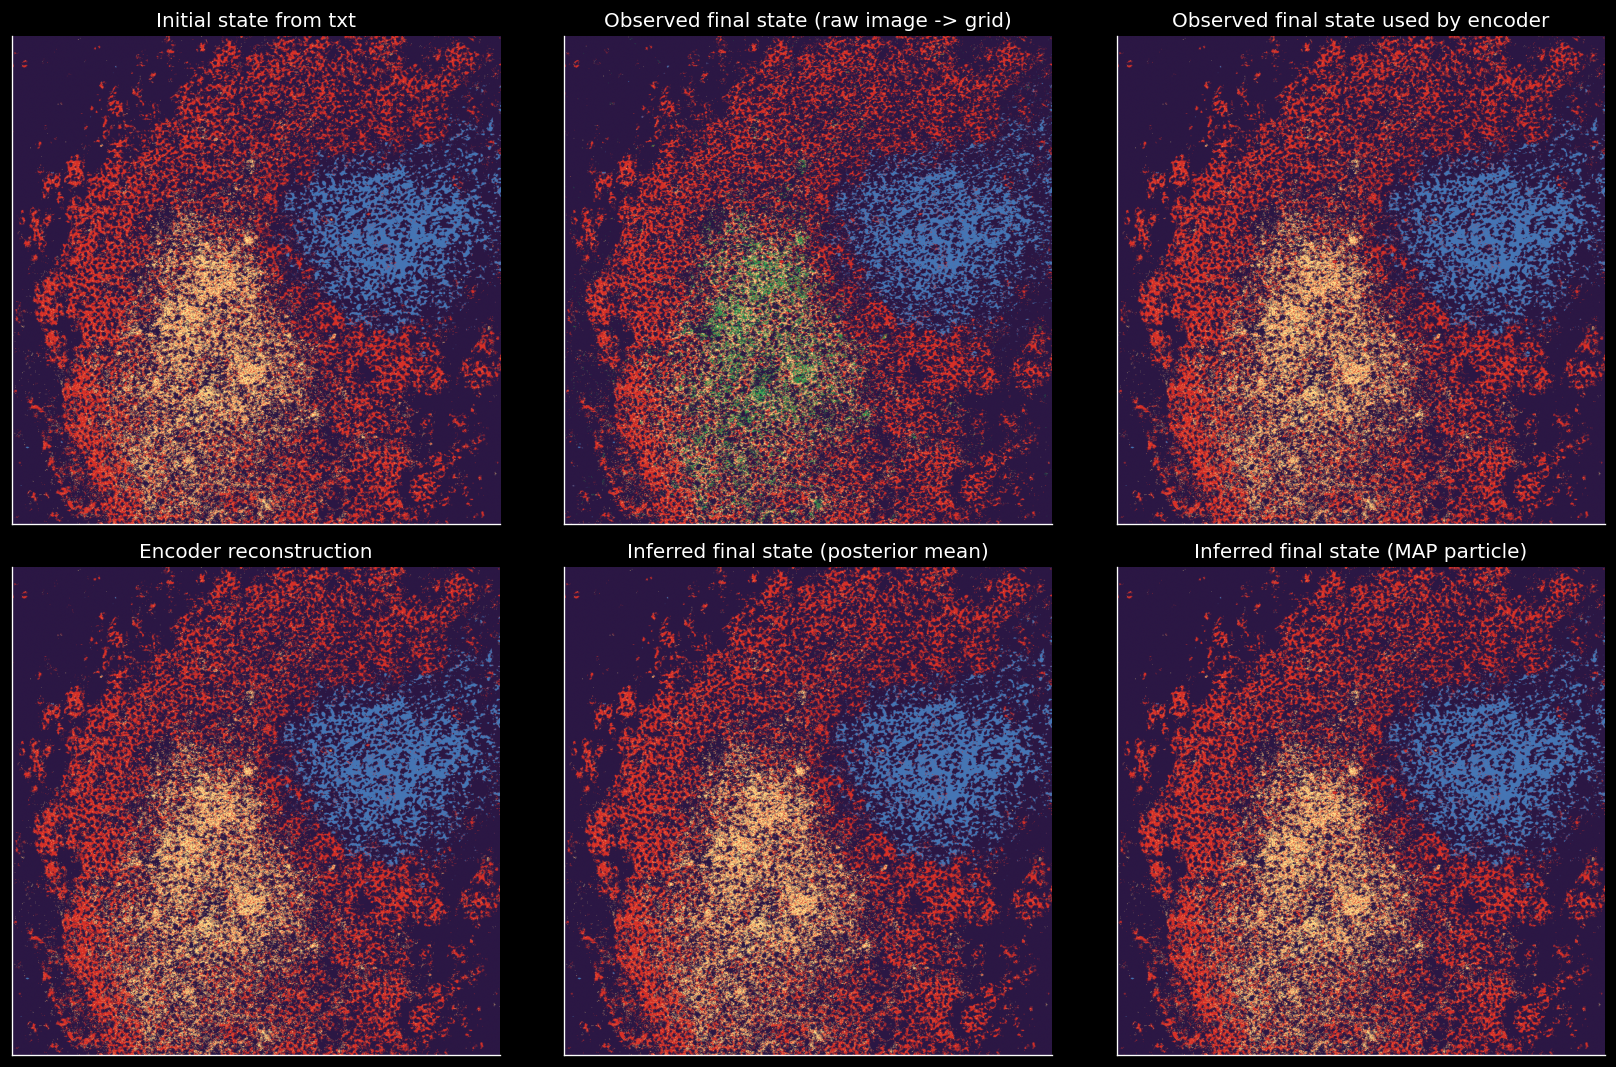

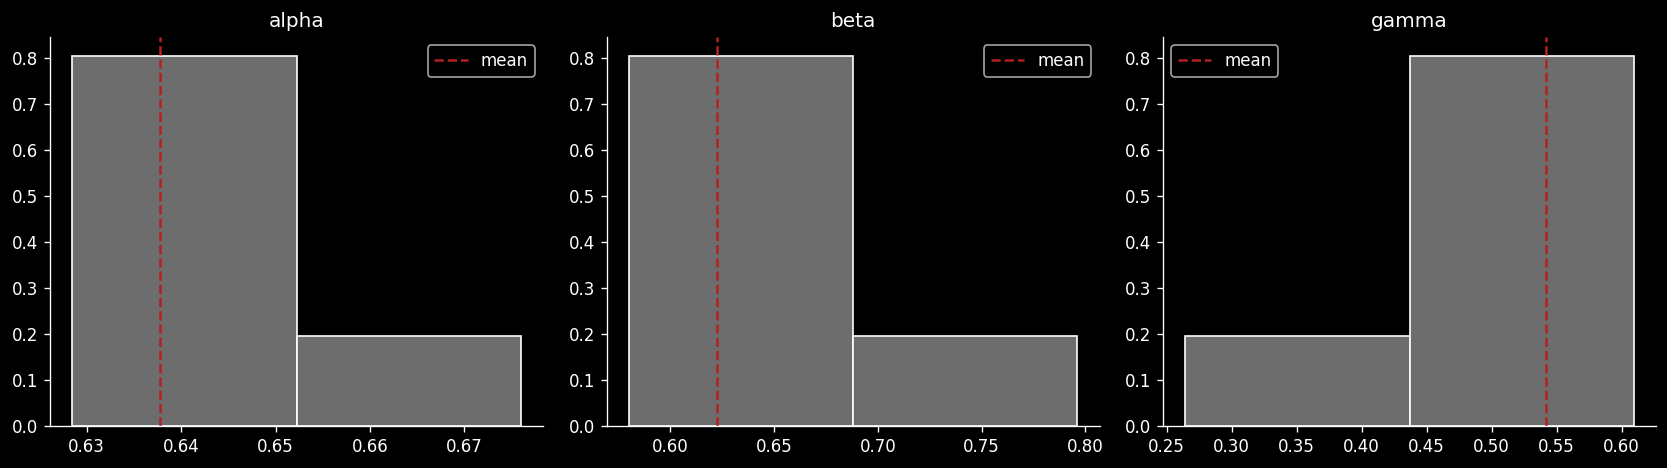

In [7]:
# -----------------------------
# 6. Result visualization
# -----------------------------
posterior_mean_sim, _ = abc_system.simulate(posterior_mean)
map_sim, _ = abc_system.simulate(map_params)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
draw_grid(axes[0, 0], initial_grid, "Initial state from txt")
if raw_image is not None:
    draw_grid(axes[0, 1], raw_image_grid, "Observed final state (raw image -> grid)")
else:
    draw_grid(axes[0, 1], observed_grid, "Observed final state")
draw_grid(axes[0, 2], observed_grid, "Observed final state used by encoder")
draw_grid(axes[1, 0], recon_grid, "Encoder reconstruction")
draw_grid(axes[1, 1], posterior_mean_sim, "Inferred final state (posterior mean)")
draw_grid(axes[1, 2], map_sim, "Inferred final state (MAP particle)")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, ax in enumerate(axes):
    ax.hist(posterior_particles[:, i], bins=min(10, len(posterior_particles)), weights=posterior_weights, color="#6d6d6d", edgecolor="white")
    ax.axvline(posterior_mean[i], color="#b22222", linestyle="--", linewidth=1.5, label="mean")
    ax.set_title(PARAM_NAMES[i])
    ax.legend()
fig.tight_layout()
plt.show()
